# HandFlow Model Evaluation Dashboard

Evaluate model metrics and visualize misclassified sequences.

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / "src"))

from handflow.utils.config import load_config
from handflow.data.loader import load_processed_data
from handflow.evaluation import ModelEvaluator, FeatureVisualizer

/Users/huynhhuy/Documents/HandKey/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# Configuration
HAND = 'right' # or 'left'
CONFIG_PATH = '../config/config.yaml'

# Locate Model and Data
MODEL_PATH = f'../models/hand_action.keras'
VAL_PATH = f'../data/processed/{HAND}_val.npz'
TRAIN_PATH = f'../data/processed/{HAND}_train.npz'

# Check existence
if not os.path.exists(MODEL_PATH):
    print(f"Error: Model not found at {MODEL_PATH}")

config = load_config(CONFIG_PATH)
print(f"Loading model from {MODEL_PATH}...")

Loading model from ../models/hand_action.keras...


In [3]:
# Load Data & Model
try:
    # Load Validation
    X_val, y_val, actions, paths_val = load_processed_data(VAL_PATH, include_paths=True)

    # Load Training (Optional)
    if os.path.exists(TRAIN_PATH):
        X_train, y_train, _ = load_processed_data(TRAIN_PATH)
        print(f"Loaded Training Samples: {len(X_train)}")
    else:
        X_train, y_train = None, None
        print("Training data not found.")

    evaluator = ModelEvaluator(MODEL_PATH, actions)
    print("✅ Model and Data loaded successfully.")
    print(f"Validation Samples: {len(X_val)}")
except Exception as e:
    print(f"Error loading: {e}")

Loaded Training Samples: 4939
✅ Model and Data loaded successfully.
Validation Samples: 872


/Users/huynhhuy/Documents/HandKey/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 32 variables whereas the saved optimizer has 62 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [4]:
# Evaluate Training Data
if X_train is not None:
   print("--- Training Data Performance ---")
   train_metrics = evaluator.evaluate(X_train, y_train)
   print(f"Train Accuracy: {train_metrics['accuracy']:.2%}")
   print(f"Train F1: {train_metrics['f1']:.2f}")
else:
   print("Skipping training evaluation.")

--- Training Data Performance ---
Train Accuracy: 98.89%
Train F1: 0.99


In [5]:
# Normalize Validation Performance
print("\n--- Validation Data Performance ---")
metrics = evaluator.evaluate(X_val, y_val)

print(f"Accuracy: {metrics['accuracy']:.2%}")
print(f"F1 Score: {metrics['f1']:.2f}")
print("\nClassification Report:")
display(pd.DataFrame(metrics['report']).transpose())


--- Validation Data Performance ---
Accuracy: 97.82%
F1 Score: 0.98

Classification Report:


,precision,recall,f1-score,support
none,1.000000,0.957672,0.978378,378.000000
horizontal_swipe,0.972973,1.000000,0.986301,72.000000
swipeup,0.967742,1.000000,0.983607,30.000000
thumb_left,1.000000,1.000000,1.000000,19.000000
thumb_right,0.900000,1.000000,0.947368,27.000000
5_fingers_close,0.975610,1.000000,0.987654,40.000000
pointyclick,0.882353,1.000000,0.937500,15.000000
middleclick,0.900000,1.000000,0.947368,18.000000
touch_hover,0.948980,0.989362,0.968750,94.000000
touch_hold,0.965909,0.988372,0.977011,86.000000


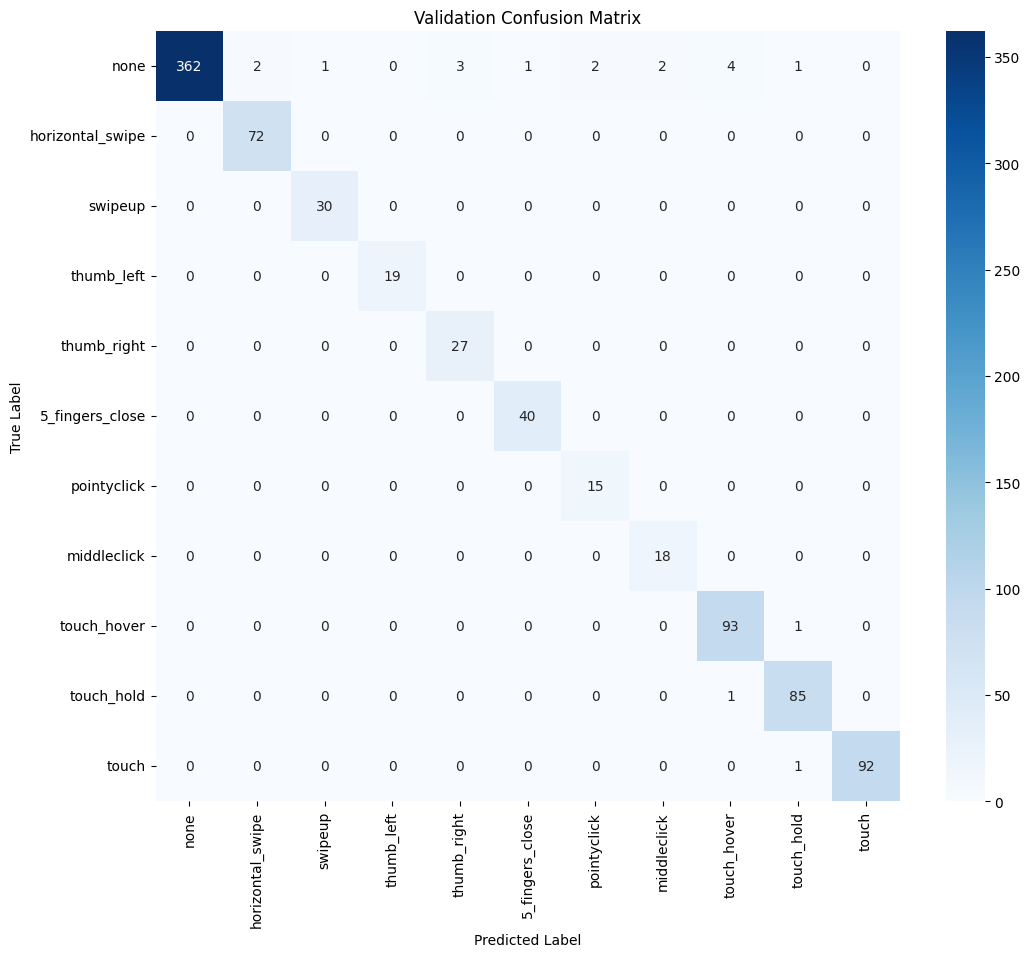

In [6]:
# Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', 
            xticklabels=actions, yticklabels=actions, cmap='Blues')
plt.title('Validation Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [7]:
# Misclassified Samples Analysis
misclassified = evaluator.get_misclassified_samples(X_val, y_val, paths_val)
print(f"Found {len(misclassified)} misclassified samples.")
print(misclassified)

# Show summary of first few failures
summary_df = pd.DataFrame([{k:v for k,v in m.items() if k != 'data'} for m in misclassified])
if not summary_df.empty:
    display(summary_df)
else:
    print("No misclassified samples!")

Found 19 misclassified samples.
[{'index': 27, 'true_label': 'none', 'pred_label': '5_fingers_close', 'true_idx': 0, 'pred_idx': 5, 'confidence': 0.77982825, 'data': array([[ 0.        ,  0.        ,  0.        , ...,  0.01903849,
         0.3770923 ,  0.33724535],
       [ 0.        ,  0.        ,  0.        , ...,  0.0251788 ,
         0.37763706,  0.35606438],
       [ 0.        ,  0.        ,  0.        , ...,  0.01675403,
         0.32018232,  0.39391398],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -0.00596828,
         0.10495503,  0.34617513],
       [ 0.        ,  0.        ,  0.        , ...,  0.00677953,
         0.10160792,  0.33758858],
       [ 0.        ,  0.        ,  0.        , ..., -0.00592692,
         0.1510988 ,  0.3176589 ]], dtype=float32), 'path': 'right_mp_data/none/287'}, {'index': 86, 'true_label': 'none', 'pred_label': 'pointyclick', 'true_idx': 0, 'pred_idx': 6, 'confidence': 0.6772426, 'data': array([[ 0.        ,  0.        ,  0.     

,index,true_label,pred_label,true_idx,pred_idx,confidence,path
0,27,none,5_fingers_close,0,5,0.779828,right_mp_data/none/287
1,86,none,pointyclick,0,6,0.677243,right_mp_data/none/1202
2,111,none,thumb_right,0,4,0.518034,right_mp_data/none/2538
3,183,touch,touch_hold,10,9,0.976648,right_mp_data/touch/611
4,207,none,touch_hover,0,8,0.507821,right_mp_data/none/162
5,212,none,horizontal_swipe,0,1,0.513394,right_mp_data/none/1600
6,284,touch_hover,touch_hold,8,9,0.597151,right_mp_data/touch_hover/156
7,319,none,middleclick,0,7,0.975329,right_mp_data/none/1586
8,332,none,thumb_right,0,4,0.932134,right_mp_data/none/2539
9,419,none,horizontal_swipe,0,1,0.480165,right_mp_data/none/2180


## Visualization of Misclassified Sequences
Iterate through the `misclassified` list to view animation and feature graphs.

In [8]:
def analyze_sample(sample_idx_in_list):
    if not misclassified:
        print("No errors to analyze.")
        return

    if sample_idx_in_list >= len(misclassified):
        print(f"Index {sample_idx_in_list} out of range (Total: {len(misclassified)})")
        return
        
    sample = misclassified[sample_idx_in_list]
    print(f"Analyzing Misclassified Sample #{sample_idx_in_list} (Dataset Index: {sample['index']})")
    print(f"True: {sample['true_label']} | Predicted: {sample['pred_label']} | Confidence: {sample['confidence']:.2f}")
    print(f"Raw data path: {sample['path']}")
    
    # 1. Animation (Matplotlib -> HTML JS)
    print("Generating Animation...")
    anim = FeatureVisualizer.create_gesture_animation(
        sample['data'], 
        title=f"True: {sample['true_label']} | Pred: {sample['pred_label']}"
    )
    display(HTML(anim.to_jshtml()))
    
    # 2. Features (Plotly Interactive)
    print("Generating Feature Plot...")
    fig = FeatureVisualizer.create_feature_plot(sample['data'])
    fig.show()

# Change index to view different failures (0, 1, 2, ...)
for idx, sample in enumerate(misclassified):
    analyze_sample(idx)

Analyzing Misclassified Sample #0 (Dataset Index: 1)
True: none | Predicted: thumb_left | Confidence: 0.57
Raw data path: right_mp_data/none/1166
Generating Animation...


Generating Feature Plot...


Analyzing Misclassified Sample #1 (Dataset Index: 92)
True: none | Predicted: touch_hover | Confidence: 0.85
Raw data path: right_mp_data/none/26
Generating Animation...


Generating Feature Plot...


Analyzing Misclassified Sample #2 (Dataset Index: 155)
True: none | Predicted: 5_fingers_close | Confidence: 0.99
Raw data path: right_mp_data/none/287
Generating Animation...


...

Generating Feature Plot...


Analyzing Misclassified Sample #11 (Dataset Index: 809)
True: touch_hold | Predicted: none | Confidence: 0.65
Raw data path: right_mp_data/touch_hold/472
Generating Animation...


Generating Feature Plot...


Analyzing Misclassified Sample #12 (Dataset Index: 814)
True: touch | Predicted: touch_hover | Confidence: 0.73
Raw data path: right_mp_data/touch/166
Generating Animation...


Generating Feature Plot...
